In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                             recall_score, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load processed data
df = pd.read_csv('../data/processed/processed_data.csv')

print("Data loaded!")
print("Shape:", df.shape)
print("\nClass distribution:")
print(df['is_return'].value_counts())

Data loaded!
Shape: (111767, 30)

Class distribution:
is_return
0    110449
1      1318
Name: count, dtype: int64


In [2]:
#Separate features and target
X = df.drop('is_return', axis=1)
y = df['is_return']

#Stratified split - keeps same class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Data split complete!")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nClass distribution in Training:")
print(y_train.value_counts())
print(f"\nClass distribution in Test:")
print(y_test.value_counts())

Data split complete!
Training set: (78236, 29)
Test set: (33531, 29)

Class distribution in Training:
is_return
0    77313
1      923
Name: count, dtype: int64

Class distribution in Test:
is_return
0    33136
1      395
Name: count, dtype: int64


In [3]:
#Scale features - important for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled!")
print("Training set shape:", X_train_scaled.shape)

Features scaled!
Training set shape: (78236, 29)


In [4]:
def evaluate_model(model_name, y_test, y_pred, y_prob):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    pr_auc = average_precision_score(y_test, y_prob)
    
    print(f"\n{'='*45}")
    print(f"  {model_name} Results")
    print(f"{'='*45}")
    print(f"  Accuracy  : {accuracy:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  PR-AUC    : {pr_auc:.4f}  ← Most Important!")
    print(f"{'='*45}")
    
    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'pr_auc': pr_auc
    }

print("✅ Evaluation function ready!")

✅ Evaluation function ready!


In [5]:
#Train Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

#Predictions
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

#Evaluate
results_lr = evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)

Training Logistic Regression...

  Logistic Regression Results
  Accuracy  : 0.9902
  Precision : 0.7297
  Recall    : 0.2734
  F1 Score  : 0.3978
  PR-AUC    : 0.3891  ← Most Important!


<Figure size 700x500 with 0 Axes>

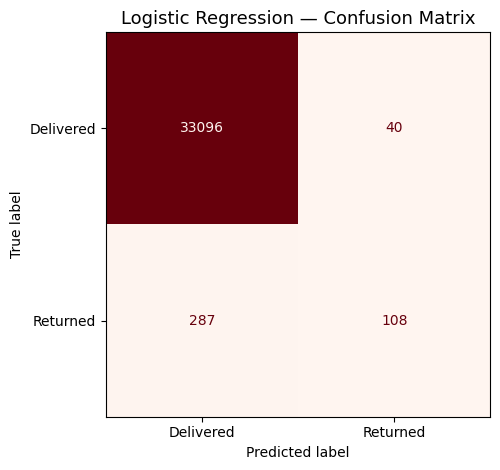

Plot saved!


In [6]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Delivered', 'Returned'])
plt.figure(figsize=(7, 5))
disp.plot(cmap='Reds', colorbar=False)
plt.title('Logistic Regression — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/lr_confusion_matrix.png')
plt.show()
print("Plot saved!")

In [7]:
from xgboost import XGBClassifier

print("Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='aucpr',
    verbosity=0
)
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Evaluate
results_xgb = evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb)

Training XGBoost...

  XGBoost Results
  Accuracy  : 0.9994
  Precision : 0.9845
  Recall    : 0.9671
  F1 Score  : 0.9757
  PR-AUC    : 0.9980  ← Most Important!


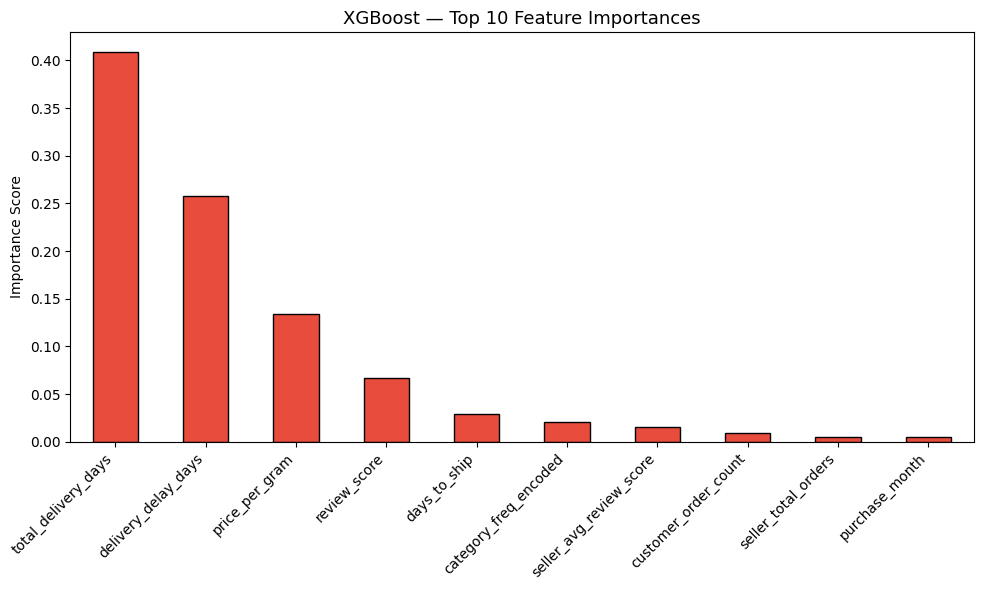

total_delivery_days        0.409027
delivery_delay_days        0.257494
price_per_gram             0.133797
review_score               0.066899
days_to_ship               0.028756
category_freq_encoded      0.020623
seller_avg_review_score    0.015434
customer_order_count       0.008805
seller_total_orders        0.005422
purchase_month             0.005271
dtype: float32


In [8]:
#Check feature importances
feat_imp = pd.Series(xgb.feature_importances_, 
                     index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar', color='#e74c3c', edgecolor='black')
plt.title('XGBoost — Top 10 Feature Importances', fontsize=13)
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/xgb_feature_importance.png')
plt.show()
print(feat_imp)

In [9]:
# Drop leakage features - these wouldn't exist at prediction time
leakage_cols = [
    'total_delivery_days',
    'delivery_delay_days', 
    'is_late_delivery',
    'days_to_ship'
]

X_train_clean = X_train.drop(columns=leakage_cols)
X_test_clean = X_test.drop(columns=leakage_cols)

# Also retrain scaler on clean data
X_train_scaled_clean = scaler.fit_transform(X_train_clean)
X_test_scaled_clean = scaler.transform(X_test_clean)

print("✅ Leakage features removed!")
print("Remaining features:", X_train_clean.shape[1])
print("Features:", X_train_clean.columns.tolist())

✅ Leakage features removed!
Remaining features: 25
Features: ['price', 'freight_value', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'review_score', 'freight_ratio', 'total_order_value', 'product_volume_cm3', 'price_per_gram', 'is_repeat_customer', 'customer_order_count', 'seller_total_orders', 'seller_avg_review_score', 'purchase_month', 'purchase_dayofweek', 'is_weekend_purchase', 'purchase_hour', 'category_freq_encoded', 'customer_state_encoded', 'seller_state_encoded']


In [10]:
print("Retraining XGBoost without leakage features...")
xgb_clean = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='aucpr',
    verbosity=0
)
xgb_clean.fit(X_train_clean, y_train)

y_pred_xgb_clean = xgb_clean.predict(X_test_clean)
y_prob_xgb_clean = xgb_clean.predict_proba(X_test_clean)[:, 1]

results_xgb_clean = evaluate_model(
    "XGBoost (No Leakage)", y_test, 
    y_pred_xgb_clean, y_prob_xgb_clean)

Retraining XGBoost without leakage features...

  XGBoost (No Leakage) Results
  Accuracy  : 0.9961
  Precision : 0.9647
  Recall    : 0.6911
  F1 Score  : 0.8053
  PR-AUC    : 0.8134  ← Most Important!


In [11]:
print("Retraining Logistic Regression without leakage features...")
lr_clean = LogisticRegression(random_state=42, max_iter=1000)
lr_clean.fit(X_train_scaled_clean, y_train)

y_pred_lr_clean = lr_clean.predict(X_test_scaled_clean)
y_prob_lr_clean = lr_clean.predict_proba(X_test_scaled_clean)[:, 1]

results_lr_clean = evaluate_model(
    "Logistic Regression (No Leakage)", y_test,
    y_pred_lr_clean, y_prob_lr_clean)

Retraining Logistic Regression without leakage features...

  Logistic Regression (No Leakage) Results
  Accuracy  : 0.9885
  Precision : 0.5735
  Recall    : 0.0987
  F1 Score  : 0.1685
  PR-AUC    : 0.3202  ← Most Important!


In [12]:
from lightgbm import LGBMClassifier
import time

print("Training LightGBM...")
start = time.time()

lgbm = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)
lgbm.fit(X_train_clean, y_train)

lgbm_time = time.time() - start

y_pred_lgbm = lgbm.predict(X_test_clean)
y_prob_lgbm = lgbm.predict_proba(X_test_clean)[:, 1]

results_lgbm = evaluate_model(
    "LightGBM", y_test,
    y_pred_lgbm, y_prob_lgbm)

# Also record XGBoost time for comparison
start = time.time()
xgb_clean.fit(X_train_clean, y_train)
xgb_time = time.time() - start

print(f"\n⏱️ Training Time Comparison:")
print(f"XGBoost  : {xgb_time:.2f} seconds")
print(f"LightGBM : {lgbm_time:.2f} seconds")

Training LightGBM...

  LightGBM Results
  Accuracy  : 0.9962
  Precision : 0.9433
  Recall    : 0.7165
  F1 Score  : 0.8144
  PR-AUC    : 0.8104  ← Most Important!

⏱️ Training Time Comparison:
XGBoost  : 0.75 seconds
LightGBM : 3.42 seconds


In [13]:
from imblearn.over_sampling import SMOTE

print("Applying SMOTE to training data only...")
print(f"Before SMOTE: {y_train.value_counts().to_dict()}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_clean, y_train)

print(f"After SMOTE: {pd.Series(y_train_smote).value_counts().to_dict()}")
print(f"\nTraining set size: {X_train_clean.shape[0]} → {X_train_smote.shape[0]}")

Applying SMOTE to training data only...
Before SMOTE: {0: 77313, 1: 923}
After SMOTE: {0: 77313, 1: 77313}

Training set size: 78236 → 154626


In [14]:
print("Training XGBoost with SMOTE...")
xgb_smote = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='aucpr',
    verbosity=0
)
xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb_smote = xgb_smote.predict(X_test_clean)
y_prob_xgb_smote = xgb_smote.predict_proba(X_test_clean)[:, 1]

results_xgb_smote = evaluate_model(
    "XGBoost + SMOTE", y_test,
    y_pred_xgb_smote, y_prob_xgb_smote)

Training XGBoost with SMOTE...

  XGBoost + SMOTE Results
  Accuracy  : 0.9949
  Precision : 0.8309
  Recall    : 0.7089
  F1 Score  : 0.7650
  PR-AUC    : 0.7833  ← Most Important!


In [15]:
print("Training LightGBM with SMOTE...")
lgbm_smote = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)
lgbm_smote.fit(X_train_smote, y_train_smote)

y_pred_lgbm_smote = lgbm_smote.predict(X_test_clean)
y_prob_lgbm_smote = lgbm_smote.predict_proba(X_test_clean)[:, 1]

results_lgbm_smote = evaluate_model(
    "LightGBM + SMOTE", y_test,
    y_pred_lgbm_smote, y_prob_lgbm_smote)

Training LightGBM with SMOTE...

  LightGBM + SMOTE Results
  Accuracy  : 0.9949
  Precision : 0.8415
  Recall    : 0.6987
  F1 Score  : 0.7635
  PR-AUC    : 0.7819  ← Most Important!


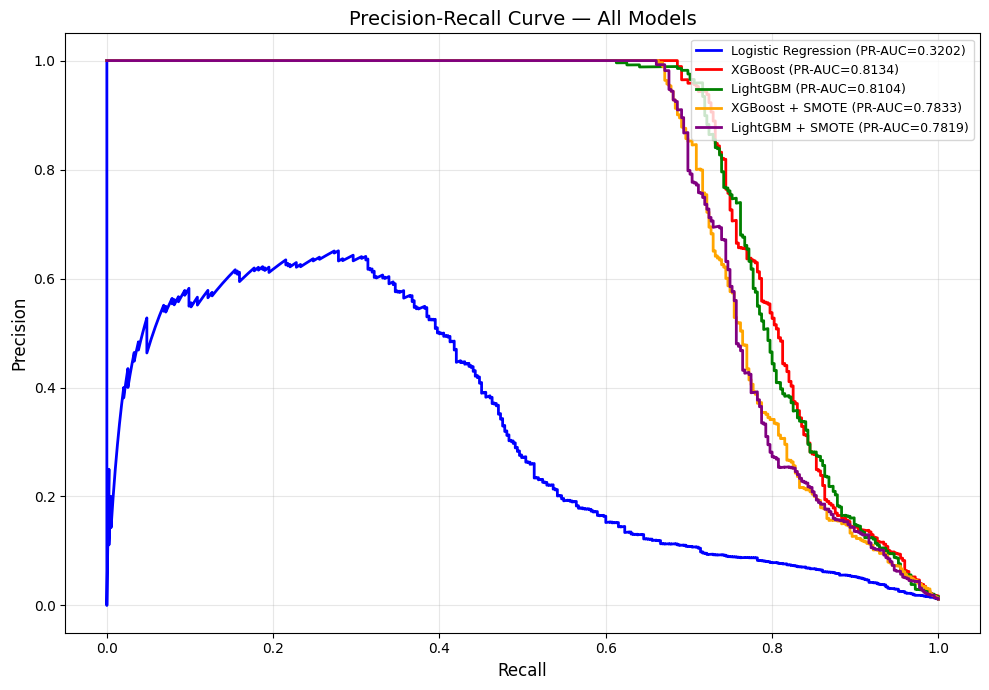

Plot saved!


In [19]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(10, 7))

# Plot each model
models_data = [
    ("Logistic Regression", y_prob_lr_clean, "blue"),
    ("XGBoost", y_prob_xgb_clean, "red"),
    ("LightGBM", y_prob_lgbm, "green"),
    ("XGBoost + SMOTE", y_prob_xgb_smote, "orange"),
    ("LightGBM + SMOTE", y_prob_lgbm_smote, "purple"),
]

for name, y_prob, color in models_data:
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    auc = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, color=color, 
             label=f"{name} (PR-AUC={auc:.4f})", linewidth=2)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve — All Models', fontsize=14)
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/pr_curves.png')
plt.show()
print("Plot saved!")